In [1]:
import pandas as pd
from IPython.display import display
import matplotlib.pyplot as plt

In [2]:
raw_income = pd.read_csv("data/Chicago_Median_Income_By_Community_Area.csv")
raw_emission = pd.read_csv("data/CommunityAreas_LocalEmission2019.csv")

display(raw_income.head())
raw_emission.head()

,Layer,Name,GEOID,INC_2020-2024,PCI_2020-2024
0,NaN,NaN,NaN,"Median household income, 2020-2024","Per capita income, 2020-2024"
1,Community area,Rogers Park,1.0,64982.84252006701,41401.316073557224
2,Community area,Norwood Park,10.0,117196.55685334843,53787.75290118216
3,Community area,Jefferson Park,11.0,99973.6803472109,51002.44814039693
4,Community area,Forest Glen,12.0,143029.53249393537,72837.37767535771


,OBJECTID,COMMUNITY,CCA_TXT,CCA_NUM,ID,ID_1,GEO,TYPE,COUNTY,AREA,...,RES_NG_B_2,SOLAR_POT,SOLSMART,Acres,Square_met,Sq_mi,Sq_ft,ft,Shape__Area,Shape__Length
0,1,DOUGLAS,35,35,35,35,Douglas,Chicago Community Area,Cook,1053,...,57.0,37.00,NaN,0.0,0.0,0,0.0,0.0,7.704649e+06,12698.313344
1,2,OAKLAND,36,36,36,36,Oakland,Chicago Community Area,Cook,372,...,59.0,9.00,NaN,0.0,0.0,0,0.0,0.0,2.831666e+06,8005.423363
2,3,FULLER PARK,37,37,37,37,Fuller Park,Chicago Community Area,Cook,457,...,63.0,15.00,NaN,0.0,0.0,0,0.0,0.0,3.332881e+06,10378.594979
3,4,GRAND BOULEVARD,38,38,38,38,Grand Boulevard,Chicago Community Area,Cook,1113,...,61.0,29.00,NaN,0.0,0.0,0,0.0,0.0,8.115726e+06,11537.863492
4,5,KENWOOD,39,39,39,39,Kenwood,Chicago Community Area,Cook,667,...,53.0,27.00,NaN,0.0,0.0,0,0.0,0.0,4.864825e+06,9538.748366


In [3]:
income_clean = raw_income.dropna(subset=["GEOID"]).copy()
income_clean["GEOID"] = income_clean["GEOID"].astype(int)
income_clean["median_household_income"] = pd.to_numeric(income_clean["INC_2020-2024"])
income_clean["per_capita_income"] = pd.to_numeric(income_clean["PCI_2020-2024"])
income_clean[["GEOID", "Name", "median_household_income", "per_capita_income"]].head()

display(raw_emission.isna().sum())
raw_emission["COMMUNITY"].head()

OBJECTID         0
COMMUNITY        0
CCA_TXT          0
CCA_NUM          0
ID               0
                ..
Sq_mi            0
Sq_ft            0
ft               0
Shape__Area      0
Shape__Length    0
Length: 67, dtype: int64

0            DOUGLAS
1            OAKLAND
2        FULLER PARK
3    GRAND BOULEVARD
4            KENWOOD
Name: COMMUNITY, dtype: str

In [4]:
null_counts = raw_emission.isna().sum()
null_counts[null_counts > 0]

SOLSMART    77
dtype: int64

In [5]:
income_clean["join_key"] = income_clean["Name"].str.upper().str.replace("'", "", regex=False)
raw_emission["join_key"] = raw_emission["COMMUNITY"].str.upper().str.replace("'", "", regex=False)

merged = income_clean.merge(raw_emission, on="join_key", how="inner")
merged.shape

(77, 75)

In [6]:
merged.columns.tolist()

['Layer',
 'Name',
 'GEOID',
 'INC_2020-2024',
 'PCI_2020-2024',
 'median_household_income',
 'per_capita_income',
 'join_key',
 'OBJECTID',
 'COMMUNITY',
 'CCA_TXT',
 'CCA_NUM',
 'ID',
 'ID_1',
 'GEO',
 'TYPE',
 'COUNTY',
 'AREA',
 'POP',
 'JOBS',
 'INCOME',
 'HOUSEHOLDS',
 'SF_HU',
 'OCC_OWN',
 'TREE_COV',
 'IMP_SUR',
 'GRC_MEM',
 'RES_ELE_CO',
 'NONRES_ELE',
 'RES_NG_CO2',
 'NONRES_NG_',
 'ONROAD_CO2',
 'ONROAD_COM',
 'ONROAD_PAS',
 'ONROAD_PUB',
 'WASTE_CO2E',
 'RES_ELE__1',
 'NONRES_E_1',
 'RES_NG_C_1',
 'NONRES_NG1',
 'ONROAD_C_1',
 'WASTE_CO_1',
 'EV_COUNT',
 'EV_PERCENT',
 'EV_STA_L2',
 'EV_STA_DCF',
 'EV_STA_TOT',
 'WALKABILIY',
 'TRAN_AVAIL',
 'MODE_DRIVE',
 'MODE_POOL',
 'MODE_TRANS',
 'MODE_WALK_',
 'MODE_OTHER',
 'RES_VMT',
 'HH_VEHICLE',
 'RES_ELE_KW',
 'NONRES_E_2',
 'RES_NG_BTU',
 'NONRES_N_1',
 'RES_ELE__2',
 'NONRES_E_3',
 'RES_NG_B_1',
 'NONRES_N_2',
 'RES_ELE__3',
 'RES_NG_B_2',
 'SOLAR_POT',
 'SOLSMART',
 'Acres',
 'Square_met',
 'Sq_mi',
 'Sq_ft',
 'ft',
 'Shape__

In [7]:
emission_cols = ["RES_ELE_CO", "NONRES_ELE", "RES_NG_CO2", "NONRES_NG_", "ONROAD_CO2", "WASTE_CO2E"]
merged["total_co2"] = merged[emission_cols].sum(axis=1)
merged[["Name", "median_household_income", "total_co2"]].sort_values("total_co2", ascending=False).head(10)

,Name,median_household_income,total_co2
75,Near North Side,128440.547158,2048492.0
25,Loop,122403.861538,1927626.0
20,Near West Side,120001.040888,1626493.0
55,Lake View,124617.153969,839104.0
16,West Town,144912.846383,797095.0
17,Austin,53210.220205,698537.0
66,Lincoln Park,161083.809659,682394.0
23,South Lawndale,60232.002443,662321.0
73,O'Hare,84182.078895,643403.0
10,Belmont Cragin,71804.049116,563850.0


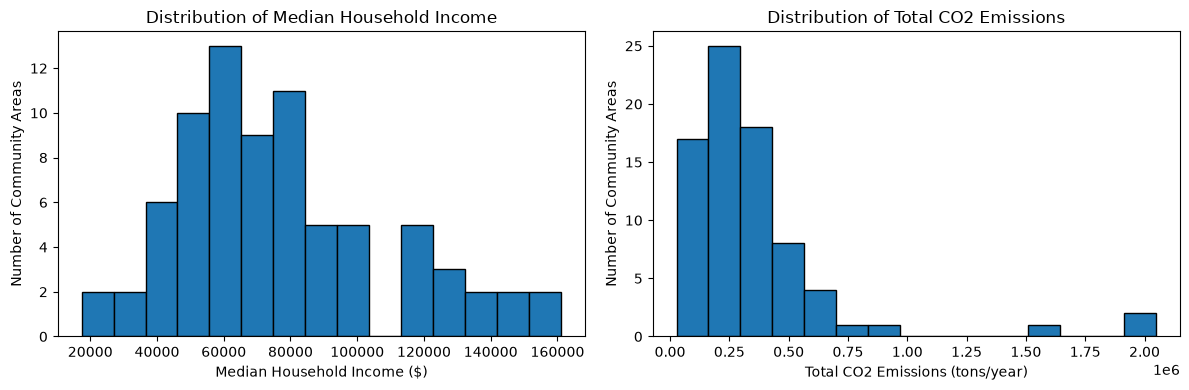

In [8]:


fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(merged["median_household_income"], bins=15, edgecolor="black")
axes[0].set_xlabel("Median Household Income ($)")
axes[0].set_ylabel("Number of Community Areas")
axes[0].set_title("Distribution of Median Household Income")

axes[1].hist(merged["total_co2"], bins=15, edgecolor="black")
axes[1].set_xlabel("Total CO2 Emissions (tons/year)")
axes[1].set_ylabel("Number of Community Areas")
axes[1].set_title("Distribution of Total CO2 Emissions")

plt.tight_layout()
plt.show()

### Distribution of Income and Total CO2 Emissions

Income is right-skewed, most areas sit between $50k-$90k, with a smaller cluster around $115k-$125k. So Chicago isn't just "poor vs rich," there's a distinct high-income group too.

CO2 is way more skewed. Most areas are under 500k tons/year but a few blow past 1.5M. Makes sense since totals include commercial/industrial emissions, not just residents, so a few business-heavy areas can dominate regardless of income.

This skew is why I don't think total emissions alone is a fair comparison across areas. Probably need a per-person version next.

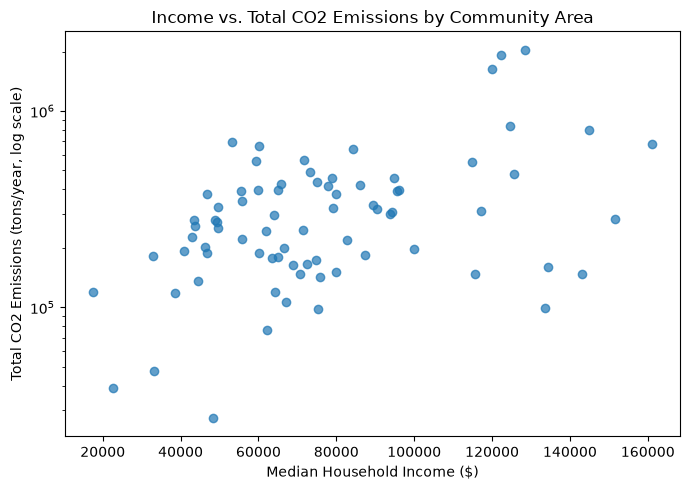

In [9]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(merged["median_household_income"], merged["total_co2"], alpha=0.7)
ax.set_yscale("log")
ax.set_xlabel("Median Household Income ($)")
ax.set_ylabel("Total CO2 Emissions (tons/year, log scale)")
ax.set_title("Income vs. Total CO2 Emissions by Community Area")
plt.tight_layout()
plt.show()

### Income vs. Total CO2 Emissions

There's a loose positive trend, higher income areas generally emit more. But it's noisy. Some $50k-$65k areas emit as much as the wealthiest ones, and the top 3 emitters aren't even the richest areas.

Kind of expected (more money, more commercial activity nearby) but the correlation is weaker than I thought it'd be. Income alone isn't explaining much here, something else is driving the outliers.

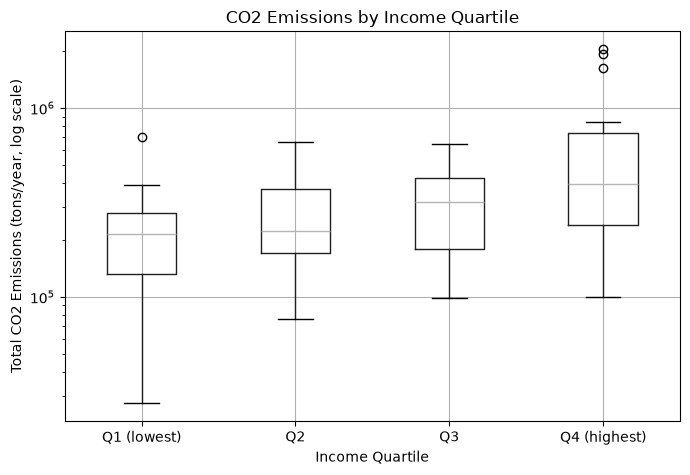

In [10]:
merged["income_quartile"] = pd.qcut(merged["median_household_income"], 4, labels=["Q1 (lowest)", "Q2", "Q3", "Q4 (highest)"])

fig, ax = plt.subplots(figsize=(7, 5))
merged.boxplot(column="total_co2", by="income_quartile", ax=ax)
ax.set_yscale("log")
ax.set_xlabel("Income Quartile")
ax.set_ylabel("Total CO2 Emissions (tons/year, log scale)")
ax.set_title("CO2 Emissions by Income Quartile")
plt.suptitle("")
plt.tight_layout()
plt.show()

### CO2 Emissions by Income Quartile

Median CO2 climbs from Q1 to Q4, and the spread gets wider too. Q4 has the highest median and three big outliers over 1.5M tons.

Rising median fits the scatter plot. But Q4's outliers are probably not "rich residents polluting more," they're likely areas like the Loop that mix wealthy residents with massive commercial emissions. Total CO2 can't tell those apart.

This is the main reason I want to switch to a per-capita CO2 metric, total emissions are hiding a density/commercial effect, not just an income effect.

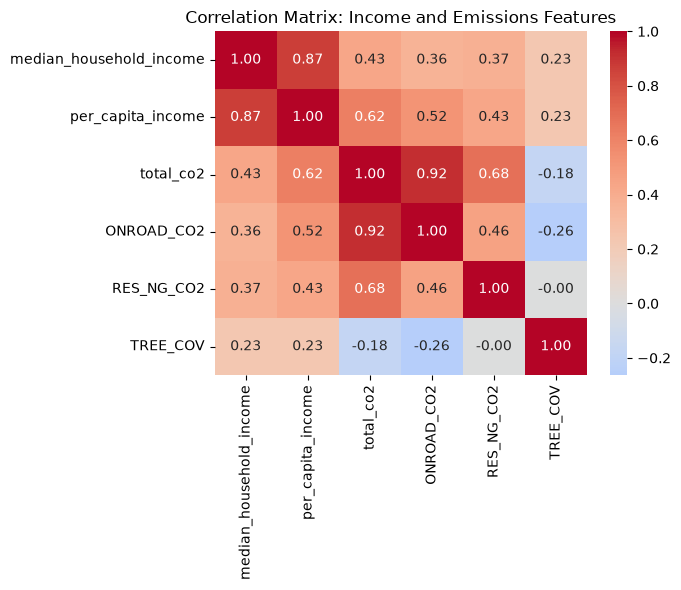

In [11]:
import seaborn as sns

corr_cols = ["median_household_income", "per_capita_income", "total_co2", "ONROAD_CO2", "RES_NG_CO2", "TREE_COV"]
corr_matrix = merged[corr_cols].corr()

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
ax.set_title("Correlation Matrix: Income and Emissions Features")
plt.tight_layout()
plt.show()

### Correlation Matrix: Income and Emissions Features

Per-capita income correlates with total_co2 more than household income does (0.62 vs 0.43), so per-capita is probably the better variable to use going forward.

Biggest finding: on-road emissions correlate with total CO2 at 0.92. That's huge, it means total emissions are basically a transportation story, not a "wealthy households use more energy" story. Residential gas only correlates at 0.68.

Tree cover is slightly negatively correlated with emissions and slightly positively correlated with income, small effect but it hints at an environmental equity angle worth mentioning.

Next step: normalize by population instead of using raw totals, and look at transportation emissions separately from residential since they're clearly driven by different things.